# India Air Quality API · quickstart

Hourly pollutant readings from every station in India's CPCB continuous monitoring network (553 stations, 2009 onwards) and the five US Embassy monitors, published by [XKDR Forum](https://www.xkdr.org) at **https://airquality.xkdr.org**.

This notebook uses the public **demo key**, which can read the 2024 files and is capped at 10,000 rows per API query. A key of your own has no limits: email admin@xkdr.org with your name, organisation and intended use, or read how at https://airquality.xkdr.org/signup.

What we'll do:

1. See what is published and where the stations are.
2. Pull one year of data (2024, about 95 MB of Parquet) into this runtime.
3. Make some plots: Delhi's November smog, cities through the year, the daily cycle, the US Embassy monitor against its CPCB neighbour.
4. Draw maps of annual and November PM2.5 by station.
5. Query the API directly for small, filtered slices.

Data: Central Pollution Control Board (CPCB) and US Department of State via AirNow. Please credit both, and *India Air Quality API, XKDR Forum*, in anything you publish.

In [ ]:
%pip install -q duckdb folium

import io, os, time, json, pathlib, requests
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from concurrent.futures import ThreadPoolExecutor

BASE = "https://airquality.xkdr.org"
KEY  = "aqi_demo_wbf92Qx21zX-Wa_Tg8Dx1nXe"          # demo key: 2024 files, 10,000 rows per API query. Replace with your own for full access.
H    = {"Authorization": f"Bearer {KEY}"}

plt.rcParams.update({"figure.figsize": (11, 4.2), "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25, "font.size": 11})
CORAL, INK = "#f57d6a", "#111111"

## 1. What is published

Every export writes a manifest describing the files: one Parquet file per month, sorted by station, pollutant and time, plus a stations table and a parameters table.

In [ ]:
m = requests.get(f"{BASE}/v1/files/v1/_manifest.json", headers=H).json()
months = m["measurements"]["months"]
print(f'{m["measurements"]["rows"]:,} hourly readings in {len(months)} month files ({m["measurements"]["bytes"]/1e6:.0f} MB), '
      f'{months[0]["year"]}-{months[0]["month"]:02d} to {months[-1]["year"]}-{months[-1]["month"]:02d}; exported {m["exported_at"][:10]}')
print(m["timezone_note"])
pd.DataFrame(months).assign(mb=lambda d: d.bytes/1e6).groupby("year")[["rows","mb"]].sum().T.round(0)

196,521,834 hourly readings in 207 month files (410 MB), 2009-01 to 2026-03; exported 2026-09-09
collected_at is a naive timestamp in Indian Standard Time (UTC+05:30).


year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
rows,411104.0,624748.0,943150.0,1038911.0,900444.0,793015.0,1615509.0,2437491.0,3359175.0,9155408.0,15012747.0,18778573.0,23640744.0,28572485.0,40156611.0,46937170.0,2140502.0,4047.0
mb,1.0,2.0,2.0,3.0,2.0,2.0,4.0,6.0,7.0,18.0,30.0,37.0,47.0,56.0,100.0,88.0,5.0,0.0


## 2. Stations

`stations.parquet` has one row per station with coordinates, first and last reading, and the pollutants it reports. Station ids are CPCB's site numbers (`site_103`) or the embassy ids (`DS1010001`).

In [ ]:
def get_parquet(key):
    r = requests.get(f"{BASE}/v1/files/{key}", headers=H); r.raise_for_status()
    return pd.read_parquet(io.BytesIO(r.content))

stations = get_parquet("v1/stations.parquet")
params   = get_parquet("v1/parameters.parquet")
print(len(stations), "stations;", stations.latitude.notna().sum(), "with coordinates")
display(params[["parameter_name", "unit", "n_stations", "n_rows"]])
stations.sample(5, random_state=1)[["station_id", "station_name", "city_name", "state_name", "source", "first_seen", "last_seen"]]

558 stations; 496 with coordinates


,parameter_name,unit,n_stations,n_rows
0,PM2.5,µg/m³,554,17844093
1,NOx,ppb,544,17506764
2,NO2,µg/m³,549,17445236
3,NO,µg/m³,543,17105758
4,CO,mg/m³,546,16961824
5,SO2,µg/m³,529,16722073
6,PM10,µg/m³,545,16587252
7,Ozone,µg/m³,530,16499316
8,Benzene,µg/m³,491,14160901
9,NH3,µg/m³,490,14043209


,station_id,station_name,city_name,state_name,source,first_seen,last_seen
440,site_5603,"Kalindi Kunj, Khurja - UPPCB",Khurja,Uttar Pradesh,cpcb_caaqm,2022-06-02 15:00:00,2025-09-01 23:00:00
530,site_5676,OMC Colony Suakati,NaN,NaN,cpcb_caaqm,2022-11-25 12:00:00,2024-12-31 23:00:00
346,site_255,"RIMT University, Mandi Gobindgarh - PPCB",Mandi Gobindgarh,Punjab,cpcb_caaqm,2017-05-01 19:00:00,2025-09-01 23:00:00
323,site_5375,"PWD Junction, Kohima - NPCB",Kohima,Nagaland,cpcb_caaqm,2025-04-01 00:00:00,2025-09-01 23:00:00
474,site_5959,"SVSPA Campus, Barrackpore - WBPCB",Barrackpore,West Bengal,cpcb_caaqm,2023-12-01 18:00:00,2025-09-01 23:00:00


In [ ]:
import folium
# Where the monitors are. Coral = CPCB, black = US Embassy.
fmap = folium.Map(location=[22.5, 79], zoom_start=5, tiles="OpenStreetMap")
for s in stations.dropna(subset=["latitude"]).itertuples():
    folium.CircleMarker([s.latitude, s.longitude], radius=3 if s.source == "cpcb_caaqm" else 6,
                        color=CORAL if s.source == "cpcb_caaqm" else INK, fill=True, fill_opacity=.8, weight=1,
                        tooltip=f"{s.station_name} ({s.station_id})").add_to(fmap)
fmap

## 3. Pull one year

The fastest way to work with the data is to copy the month files you need into the runtime, then query them with DuckDB. Twelve files for 2024 are about 95 MB and take a few seconds with a handful of parallel connections.

In [ ]:
YEAR = 2024
DATA = pathlib.Path("data"); DATA.mkdir(exist_ok=True)
keys = [f"v1/measurements/year={YEAR}/month={mm:02d}/data.parquet" for mm in range(1, 13)]

def fetch(key):
    dest = DATA / key
    if dest.exists(): return dest.stat().st_size
    r = requests.get(f"{BASE}/v1/files/{key}", headers=H); r.raise_for_status()
    dest.parent.mkdir(parents=True, exist_ok=True); dest.write_bytes(r.content); return len(r.content)

t0 = time.time()
with ThreadPoolExecutor(8) as ex: sizes = list(ex.map(fetch, keys))
print(f"{len(keys)} files, {sum(sizes)/1e6:.0f} MB in {time.time()-t0:.1f} s")

con = duckdb.connect()
con.execute(f"""CREATE OR REPLACE VIEW m AS
  SELECT * FROM read_parquet('{DATA}/v1/measurements/*/*/data.parquet', hive_partitioning = true, hive_types = {{'year': INTEGER, 'month': INTEGER}})""")
con.sql("SELECT source, count(*) AS readings, count(DISTINCT station_id) AS stations, min(collected_at) AS first, max(collected_at) AS last FROM m GROUP BY 1")

12 files, 88 MB in 4.2 s


┌────────────┬──────────┬──────────┬─────────────────────┬─────────────────────┐
│   source   │ readings │ stations │        first        │        last         │
│  varchar   │  int64   │  int64   │      timestamp      │      timestamp      │
├────────────┼──────────┼──────────┼─────────────────────┼─────────────────────┤
│ us_embassy │    40409 │        5 │ 2024-01-01 00:30:00 │ 2024-12-31 23:30:00 │
│ cpcb_caaqm │ 46896761 │      533 │ 2024-01-01 00:00:00 │ 2024-12-31 23:00:00 │
└────────────┴──────────┴──────────┴─────────────────────┴─────────────────────┘

## 4. Plots

### Delhi, November 2024, hour by hour

Every CPCB station in Delhi, with the city-wide mean in coral. November is the post-monsoon stubble-burning and inversion season.

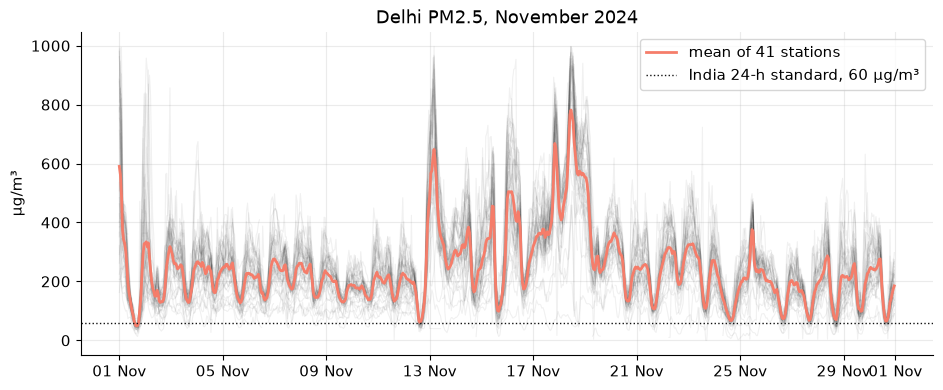

In [ ]:
delhi = con.sql("""
  SELECT station_id, collected_at, value FROM m
  WHERE city_name = 'Delhi' AND parameter_name = 'PM2.5' AND month = 11 AND value BETWEEN 0 AND 1000
""").df()
wide = delhi.pivot_table(index="collected_at", columns="station_id", values="value")
fig, ax = plt.subplots()
ax.plot(wide.index, wide.values, color=INK, alpha=.06, lw=.8)
ax.plot(wide.index, wide.mean(axis=1), color=CORAL, lw=2, label=f"mean of {wide.shape[1]} stations")
ax.axhline(60, color=INK, ls=":", lw=1, label="India 24-h standard, 60 µg/m³")
ax.set(title="Delhi PM2.5, November 2024", ylabel="µg/m³"); ax.legend(loc="upper right"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d Nov"))
plt.show()

### Five cities through the year

Daily means of PM2.5 across all stations in each city, smoothed with a 7-day rolling mean.

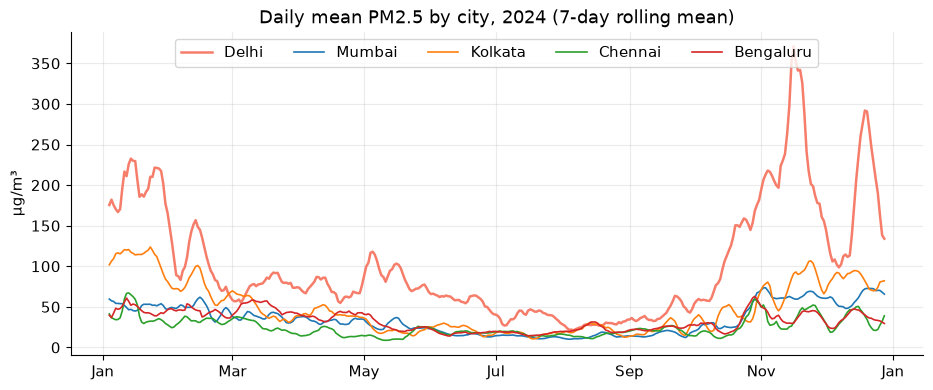

In [ ]:
cities = ["Delhi", "Mumbai", "Kolkata", "Chennai", "Bengaluru"]
daily = con.sql("""
  SELECT city_name, date_trunc('day', collected_at) AS day, avg(value) AS pm25
  FROM m WHERE parameter_name = 'PM2.5' AND city_name IN ('Delhi','Mumbai','Kolkata','Chennai','Bengaluru') AND value BETWEEN 0 AND 1000
  GROUP BY ALL ORDER BY ALL
""").df()
fig, ax = plt.subplots()
for c in cities:
    d = daily[daily.city_name == c].set_index("day").pm25.rolling(7, center=True).mean()
    ax.plot(d.index, d.values, lw=1.8 if c == "Delhi" else 1.2, color=CORAL if c == "Delhi" else None, label=c)
ax.set(title="Daily mean PM2.5 by city, 2024 (7-day rolling mean)", ylabel="µg/m³"); ax.legend(ncol=5, loc="upper center"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.show()

### The daily cycle

Mean PM2.5 by hour of day (IST). Delhi peaks overnight when the boundary layer is shallow; Mumbai's sea breeze flattens the curve.

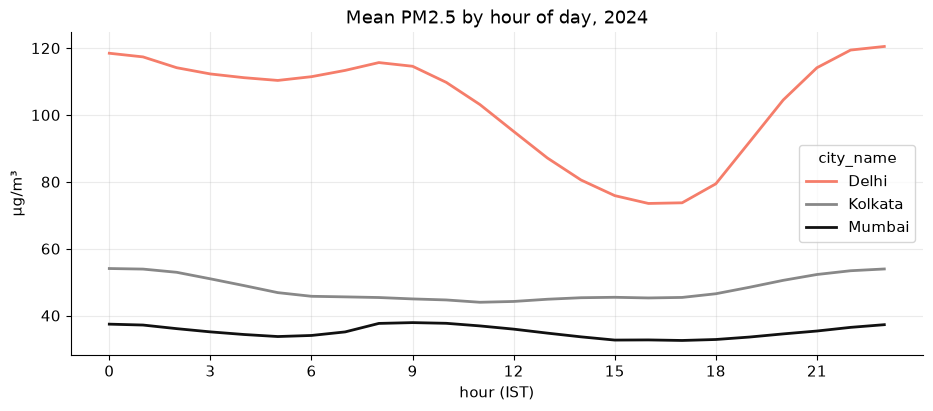

In [ ]:
diurnal = con.sql("""
  SELECT city_name, hour(collected_at) AS hr, avg(value) AS pm25
  FROM m WHERE parameter_name = 'PM2.5' AND city_name IN ('Delhi','Mumbai','Kolkata') AND value BETWEEN 0 AND 1000
  GROUP BY ALL ORDER BY ALL
""").df().pivot(index="hr", columns="city_name", values="pm25")
ax = diurnal.plot(color={"Delhi": CORAL, "Mumbai": INK, "Kolkata": "#888888"}, lw=2)
ax.set(title="Mean PM2.5 by hour of day, 2024", xlabel="hour (IST)", ylabel="µg/m³", xticks=range(0, 24, 3)); plt.show()

### Two networks, one neighbourhood

The US Embassy monitor in Delhi (`DS1010001`) and the CPCB station on Mathura Road (`site_103`) are a few kilometres apart. Comparing daily means is a quick check that the two networks agree. Embassy readings are stamped at half past the hour, so we compare daily aggregates rather than hours.

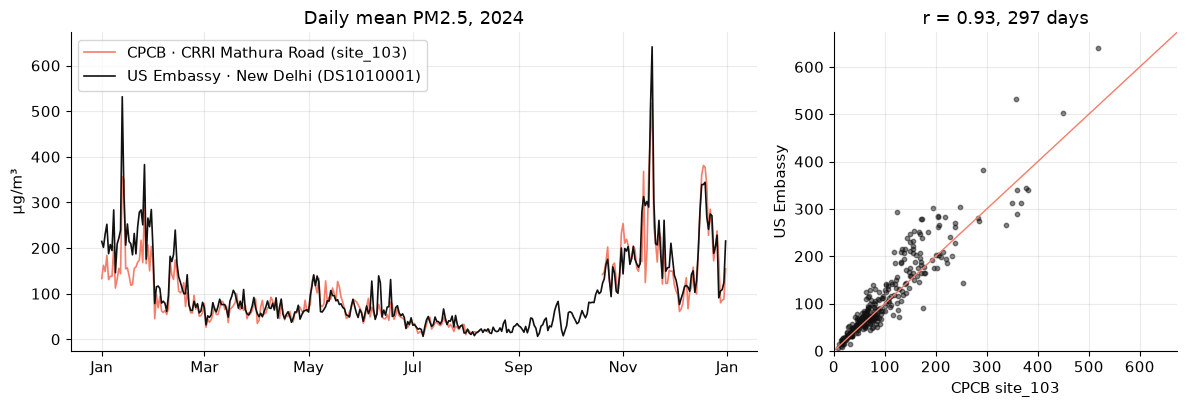

In [ ]:
pair = con.sql("""
  SELECT station_id, date_trunc('day', collected_at) AS day, avg(value) AS pm25
  FROM m WHERE parameter_name = 'PM2.5' AND station_id IN ('DS1010001', 'site_103') AND value BETWEEN 0 AND 1000
  GROUP BY ALL
""").df().pivot(index="day", columns="station_id", values="pm25")   # NaN where a network has no data that day, so gaps show as gaps
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [2, 1]})
a1.plot(pair.index, pair["site_103"], color=CORAL, lw=1.2, label="CPCB · CRRI Mathura Road (site_103)")
a1.plot(pair.index, pair["DS1010001"], color=INK, lw=1.2, label="US Embassy · New Delhi (DS1010001)")
a1.set(title="Daily mean PM2.5, 2024", ylabel="µg/m³"); a1.legend(); a1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
both = pair.dropna()
a2.scatter(both["site_103"], both["DS1010001"], s=10, color=INK, alpha=.5); lim = both.values.max() * 1.05
a2.plot([0, lim], [0, lim], color=CORAL, lw=1); a2.set(xlabel="CPCB site_103", ylabel="US Embassy", title=f"r = {both.corr().iloc[0,1]:.2f}, {len(both)} days", xlim=(0, lim), ylim=(0, lim))
plt.tight_layout(); plt.show()

## 5. Maps

Annual mean PM2.5 per station, and the same for November. Circle colour follows the value; hover for the station.

In [ ]:
import branca.colormap as cm
def station_means(where):
    df = con.sql(f"""SELECT station_id, avg(value) AS pm25, count(*) AS n FROM m
                      WHERE parameter_name = 'PM2.5' AND value BETWEEN 0 AND 1000 AND {where} GROUP BY 1 HAVING n > 500""").df()
    return df.merge(stations[["station_id", "station_name", "city_name", "latitude", "longitude"]], on="station_id").dropna(subset=["latitude"])

def pm_map(df, title, vmax=150):
    cmap = cm.LinearColormap(["#2c7bb6", "#ffffbf", "#f57d6a", "#7b1e1e"], vmin=20, vmax=vmax, caption=f"{title} (µg/m³)")
    fm = folium.Map(location=[22.5, 79], zoom_start=5, tiles="OpenStreetMap")
    for r in df.itertuples():
        folium.CircleMarker([r.latitude, r.longitude], radius=5, color=cmap(min(r.pm25, vmax)), fill=True, fill_opacity=.85, weight=.5,
                            tooltip=f"{r.station_name}: {r.pm25:.0f} µg/m³").add_to(fm)
    cmap.add_to(fm); return fm

annual = station_means("true")
print(f"{len(annual)} stations with coordinates and >500 PM2.5 readings in {YEAR}")
pm_map(annual, f"Annual mean PM2.5, {YEAR}")

481 stations with coordinates and >500 PM2.5 readings in 2024


In [ ]:
november = station_means("month = 11")
pm_map(november, f"Mean PM2.5, November {YEAR}", vmax=300)

In [ ]:
# The ten cleanest and dirtiest stations by annual mean
pd.concat([annual.nsmallest(10, "pm25").assign(rank="cleanest"), annual.nlargest(10, "pm25").assign(rank="dirtiest")])[["rank", "station_name", "city_name", "pm25"]].round(0)

,rank,station_name,city_name,pm25
394,cleanest,"Kodungaiyur, Chennai - TNPCB",Chennai,13.0
430,cleanest,"Zero Point GICI, Gangtok - SSPCB",Gangtok,13.0
9,cleanest,"Civil Lines, Bareilly - UPPCB",Sagar,15.0
299,cleanest,"Mahatma Basaveswar Colony, Kalaburgi - KSPCB",Kalaburagi,15.0
286,cleanest,"Sikulpuikawn, Aizawl - Mizoram PCB",Aizawl,17.0
235,cleanest,"IESD Banaras Hindu University, Varanasi - UPPCB",Varanasi,18.0
389,cleanest,"Ibrahimpur, Vijayapura - KSPCB",Vijayapura,18.0
302,cleanest,"Bandhavgar Colony, Satna - Birla Cement",Satna,18.0
285,cleanest,"Deen Dayal Nagar, Sagar - MPPCB",Gwalior,18.0
236,cleanest,"Bhelupur, Varanasi - UPPCB",Varanasi,18.0


## 6. The query API

For small, filtered slices you don't need the files at all: `/v1/measurements` returns JSON, CSV or Parquet, filtered by station, city, state, pollutant and dates, optionally aggregated to hourly, daily or monthly means. The demo key is capped at 10,000 rows per query; a key of your own has no cap.

The query service runs on XKDR's server behind the gateway. If it answers 503 the service is offline for the moment; everything above still works.

In [ ]:
def api(path, **params):
    r = requests.get(f"{BASE}{path}", headers=H, params=params)
    if r.status_code == 503:
        print("Query service is offline right now:", r.json().get("detail")); return None
    r.raise_for_status(); return r

r = api("/v1/meta")
if r:
    meta = r.json(); print(json.dumps({k: meta[k] for k in ("exported_at", "measurements", "your_tier", "max_rows_per_query")}, indent=1))
    r = api("/v1/measurements", city="Mumbai", parameter="PM2.5", start="2024-10-01", end="2024-12-31", agg="daily", format="csv")
    mumbai = pd.read_csv(io.StringIO(r.text), parse_dates=["period_start"])
    print(r.headers.get("X-Row-Count"), "rows, truncated:", r.headers.get("X-Truncated"))
    ax = mumbai.groupby("period_start")["mean"].mean().plot(color=CORAL, lw=1.5)
    ax.set(title="Mumbai daily mean PM2.5 via /v1/measurements", ylabel="µg/m³"); plt.show()

Query service is offline right now: Query service is not configured.


## Next steps

* **Get your own key** for the whole archive (2009 onwards, no caps): https://airquality.xkdr.org/signup
* **Reference and more examples**: https://airquality.xkdr.org/#docs
* **Bulk files**: `GET /v1/files` lists them; `GET /v1/files/<key>` serves them with range support, so DuckDB can read them in place.

Things to know before you publish: timestamps are Indian Standard Time; values are as reported by the networks with no cleaning (this notebook drops readings outside 0 to 1000 µg/m³ as an obvious-error filter, which you may want to refine); a few dozen decommissioned stations have no coordinates.